In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

In [2]:
df = pd.read_csv("./advertising_vs_sales.csv")

In [3]:
df.head()

,Advertising_Budget_Thousands,Sales_Thousands
0,18.30,179.25
1,31.30,323.92
2,97.30,764.44
3,36.48,360.31
4,50.79,537.32


In [4]:
df.shape

(500, 2)

In [5]:
df.columns

Index(['Advertising_Budget_Thousands', 'Sales_Thousands'], dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Advertising_Budget_Thousands  500 non-null    float64
 1   Sales_Thousands               500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.isnull().sum()

Advertising_Budget_Thousands    0
Sales_Thousands                 0
dtype: int64

### Making / Defining of the model

In [18]:
X  = df[["Advertising_Budget_Thousands"]] # The prediction will be done on the this basis so independent
Y = df["Sales_Thousands"] # We need this prediction so it is dependent variable

### Training and splitting the model

In [19]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model = LinearRegression()

model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[7.9]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Advertising_Budget_Thousands']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,56.86
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


### Checking for the parameters

In [20]:
print("Intercept (c): ", model.intercept_)
print("Slope (m): ", model.coef_)

Intercept (c):  56.85771898770872
Slope (m):  [7.89972462]


### Making Predictions

In [26]:
new_sales = pd.DataFrame({"Advertising_Budget_Thousands": [234.67]})

predicted_sales = model.predict(new_sales)

print("Predicted sales for advertisement of 234.67K: ", predicted_sales[0])

Predicted sales for advertisement of 234.67K:  1910.6860949585794


### Checking the metrics

In [27]:
y_pred = model.predict(X_test)

r2 = r2_score(Y_test, y_pred)
mae = mean_absolute_error(Y_test, y_pred)
mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R suqare: {r2:.4f}")
print(f"mean_absolute_error: {mae:.2f}")
print(f"mean_squared_error: {mse:.2f}")
print(f"root_mean_squared_error: {rmse:.2f}")

R suqare: 0.9644
mean_absolute_error: 35.48
mean_squared_error: 1768.64
root_mean_squared_error: 42.06


### Comparison of parameters 

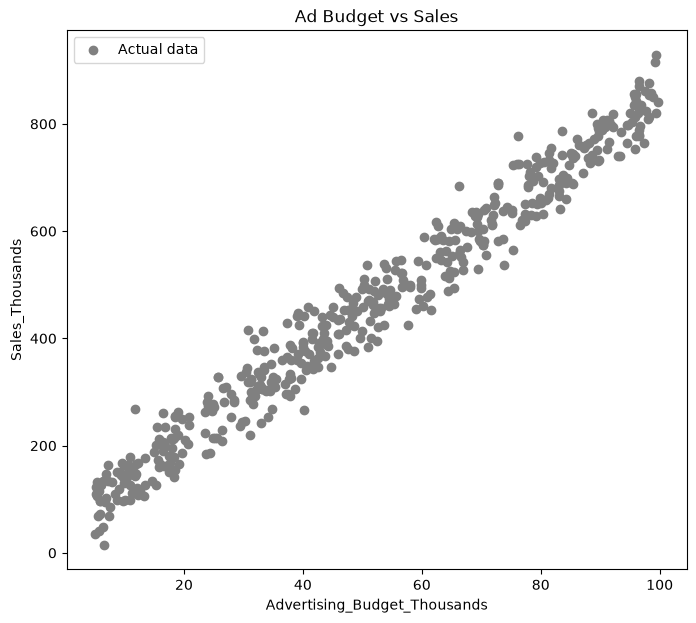

In [29]:
plt.figure(figsize=(8,7))
plt.scatter(X, Y, color="grey", label="Actual data")
plt.xlabel("Advertising_Budget_Thousands")
plt.ylabel("Sales_Thousands")
plt.title("Ad Budget vs Sales")
plt.legend()
plt.show()

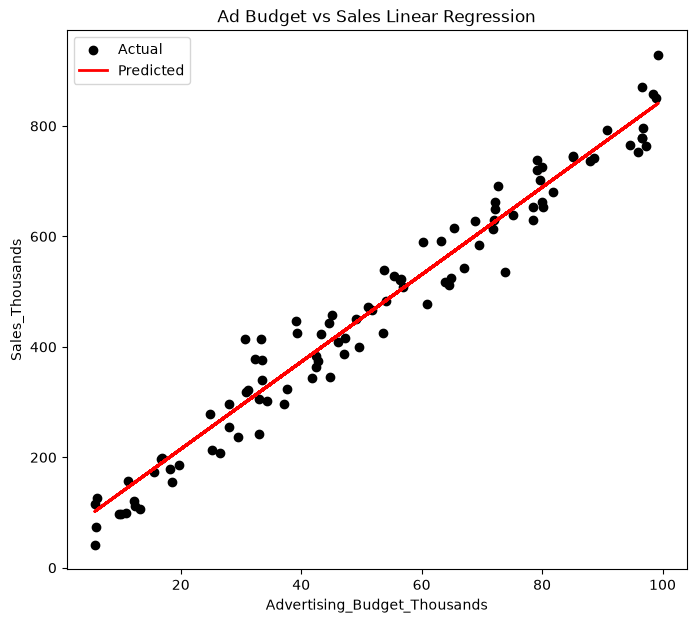

In [30]:
plt.figure(figsize=(8,7))
plt.scatter(X_test, Y_test, color="black", label="Actual")
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Predicted")
plt.xlabel("Advertising_Budget_Thousands")
plt.ylabel("Sales_Thousands")
plt.title("Ad Budget vs Sales Linear Regression")
plt.legend()
plt.show()

### Saving the model

In [32]:
joblib.dump(model, "linear_regression_assign1.pkl")

print("model saved successfully")

model saved successfully


In [33]:
X_full = df[["Advertising_Budget_Thousands"]]

df["Predicted_Sales"] = model.predict(X_full)

print(df[["Advertising_Budget_Thousands", "Sales_Thousands", "Predicted_Sales"]].head(10))

   Advertising_Budget_Thousands  Sales_Thousands  Predicted_Sales
0                         18.30           179.25       201.422679
1                         31.30           323.92       304.119100
2                         97.30           764.44       825.500924
3                         36.48           360.31       345.039673
4                         50.79           537.32       458.084732
5                         23.63           184.51       243.528212
6                         63.02           561.78       554.698364
7                         31.66           276.84       306.963000
8                         24.66           264.35       251.664928
9                         54.07           483.36       483.995829
